# KAN-CDSCO2004U  Machine Learning and Deep Learning

## Lab 11: LSTM Stock Predictor — ✅ Solution
**Estimated time: 1 hour**

### Learning Objectives
By the end of this exercise, you will be able to:
- Preprocess time series data utilizing MinMaxScaler
- Build and train an LSTM model using Keras
- Make predictions based on test data

**How to work through this notebook:**
- 🏃 **RUN** cells = Just execute the code to see the output
- ✏️ **TODO** cells = Write your own code or answer questions
- 📖 **READ** cells = Explanations to help you understand the concepts

🏃 **RUN**

### Import Libraries

In [24]:
# Import Libraries
# Author: Luca Gudi (lgg.digi@cbs.dk)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `import math, numpy, pandas...` | Imports necessary libraries for mathematical operations, data manipulation, scaling, and building the LSTM neural network. |


---

## Data Preprocessing and Training Set Preparation

📖 **READ**

In this session, we will prepare a time-series dataset for model training. Follow these steps.

🏃 **RUN**

Execute the cell below to load the dataset and prepare the feature arrays.

In [9]:
# Load the data
dataset = pd.read_csv('price.csv')
training_set = dataset.iloc[:, 1:2]
dataset = training_set.values

# Set 80 percent of the data as training dataset. Note, it is not split into train and test yet.
training_data_len = math.ceil(len(dataset) * 0.8)

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `pd.read_csv('price.csv')` | Loads the stock price data from a CSV file into a pandas DataFrame. |\n| `dataset.iloc[:, 1:2]` | Selects the specfic column containing the price data to be used for training. |\n| `math.ceil(...)` | Calculates the number of rows to use for the training set (80% of the total data). |


✏️ **TODO**

### Step 1: Scale the Data

**Objective:** Scale your dataset so that all values are between 0 and 1.

**Instructions:**
- Import `MinMaxScaler` from `sklearn.preprocessing`.
- Initialize the scaler with `feature_range=(0, 1)`.
- Fit and transform your dataset to obtain scaled data.
- Define a variable (e.g., `training_data_len`) to specify the number of rows used for training.
- Slice the scaled data to extract the training dataset.
- Print the training dataset to verify that the scaling has been applied correctly.

In [10]:
# [TODO] Pre-processing Stage: Scale data between 0 and 1. You can use MinMaxScaler.
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
train_data = scaled_data[0:training_data_len, :]
print(train_data)

[[0.6202352 ]
 [0.62226277]
 [0.64436334]
 ...
 [0.13260341]
 [0.13807786]
 [0.15794809]]


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `MinMaxScaler(...)` | Initializes a scaler to transform the dataset values into a specific range, here between 0 and 1. |\n| `scaler.fit_transform(...)` | Applies the scaling transformation to the dataset. |\n| `scaled_data[0:training_data_len, :]` | Extracts the previously determined 80% of the data to serve as the training set. |


✏️ **TODO**

### Step 2: Create Training Data with 80 Timesteps

**Objective:** Construct sequences for training where each sample includes 80 time steps.

**Instructions:**
- Initialize two empty lists: one for `x_train` (to hold the sequences) and another for `y_train` (to hold the corresponding target values).
- Loop through the training data starting from the 80th data point.
- For each iteration:
  - Append the previous 80 time step values to `x_train`.
  - Append the current value to `y_train` as the target.
- Convert both `x_train` and `y_train` to NumPy arrays.
- Print the shape of `x_train` to confirm that it contains the correct number of samples and timesteps.

In [11]:
# [TODO] Create train data with 80 timesteps. Here, split into train and test data.
x_train = []
y_train = []

for i in range(80, len(train_data)):
    x_train.append(train_data[i-80:i, 0])
    y_train.append(train_data[i,0])

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `x_train.append(...)` | Creates sequences of 80 historical price points to serve as input variables. |\n| `y_train.append(...)` | Sets the next price point immediately following the 80-item sequence as the target variable to be predicted. |


🏃 **RUN**

Execute the cell below to print the training set shape.

In [12]:
x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)

(1548, 80)


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `np.array(...)` | Converts the lists of sequences into NumPy arrays, which are required for training the deep learning model. |


✏️ **TODO**

### Step 3: Reshape the Data for Model Input

**Objective:** Reshape `x_train` into a 3D array suitable for time-series models.

**Instructions:**
- Reshape `x_train` so that it has the dimensions `(number of samples, 80 timesteps, 1 feature per timestep)`.
- This step is crucial for compatibility with deep learning models, which expect a 3D input shape.
- Print the reshaped `x_train` and `y_train` to verify the data preprocessing workflow.

In [13]:
# [TODO] Convert the data into a 3D array (np.array) with x_train samples, 80 timestamps, and one feature at each step.
# [Hint] Remember to reshape the x-array
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `np.reshape(...)` | Modifies the shape of the training data from 2D to 3D, adding a single feature dimension expected by the LSTM layers. |


🏃 **RUN**

Execute the cell below to print the reshaped arrays.

In [14]:
# [TODO] Print training set
print(x_train)

[[[0.6202352 ]
  [0.62226277]
  [0.64436334]
  ...
  [0.75344688]
  [0.736618  ]
  [0.70721817]]

 [[0.62226277]
  [0.64436334]
  [0.61719384]
  ...
  [0.736618  ]
  [0.70721817]
  [0.74574209]]

 [[0.64436334]
  [0.61719384]
  [0.61820762]
  ...
  [0.70721817]
  [0.74574209]
  [0.7648013 ]]

 ...

 [[0.14557989]
  [0.14497161]
  [0.14801298]
  ...
  [0.14760746]
  [0.15369019]
  [0.14801298]]

 [[0.14497161]
  [0.14801298]
  [0.14476886]
  ...
  [0.15369019]
  [0.14801298]
  [0.13260341]]

 [[0.14801298]
  [0.14476886]
  [0.11719384]
  ...
  [0.14801298]
  [0.13260341]
  [0.13807786]]]


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `print(...)` | Displays the transformed training arrays to verify the preprocessing steps. |


---

## Model Construction, Training, and Prediction

✏️ **TODO**

### Step 1: Construct the LSTM Model

**Objective:** Build a sequential model with three LSTM layers, one hidden Dense layer, and one output Dense layer.

**Instructions:**
- **Import necessary modules:** Use Keras modules such as `Sequential`, `LSTM`, and `Dense`.
- **Initialize the model:** Start by creating an instance of a sequential model.
- **Add LSTM layers:**
  - **First LSTM layer:** Add an LSTM layer with 50 units. Set the `input_shape` using the training data shape and enable `return_sequences=True` since the following layer is also an LSTM.
  - **Second LSTM layer:** Add another LSTM layer with 50 units and set `return_sequences=True`.
  - **Third LSTM layer:** Add a final LSTM layer with 50 units, this time with `return_sequences=False` as it will feed into the Dense layers.
- **Add Dense layers:**
  - **Hidden layer:** Add a Dense layer with 25 units.
  - **Output layer:** Add a Dense layer with 1 unit for the final prediction.

In [15]:
# [TODO] Construct a model with three LSTM layers, one hidden layer, and an output layer.
# [Hints] First lstm layer we considered as input layer, it return sequences will be ‘True’
# as next layer is also lstm layer. Even in the second layer return sequences is ‘True’.
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences= True))
model.add(LSTM(50, return_sequences= False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `Sequential()` | Initializes a standard neural network where layers are stacked sequentially. |\n| `LSTM(...)` | Adds Long Short-Term Memory layers to process the time-series data. Setting `return_sequences=True` passes full sequences to the next layer. |\n| `Dense(...)` | Adds fully connected layers to condense the LSTM outputs and produce a single final prediction value. |


✏️ **TODO**

### Step 2: Compile the Model

**Objective:** Prepare the model for training by compiling it.

**Instructions:**
- Compile the model using the `adam` optimizer.
- Set the loss function to `mean_squared_error` to handle regression-based error calculations.
- *Tip:* This setup is standard for time-series prediction problems.

In [16]:
# [TODO]  compile the model use adam as the optimizer and mean square error as the loss function.
model.compile(optimizer='adam', loss='mean_squared_error')

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `model.compile(...)` | Configures the model by assigning an optimizer to adjust weights during training and a loss function to evaluate prediction accuracy. |


✏️ **TODO**

### Step 3: Train the Model

**Objective:** Train your model using the prepared training dataset.

**Instructions:**
- Use the `fit()` method to train the model on your training data (`x_train` and `y_train`).
- Set the batch size to 1 and use 1 epoch for this demonstration.
- *Note:* You can increase the number of epochs in future iterations to improve model performance.

In [17]:
# [TODO] Train model pass training dataset into the fit() function.
# [Hints] Set number of epochs as 1
model.fit(x_train, y_train, batch_size=1, epochs= 1)

1548/1548 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - loss: 0.0088


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `model.fit(...)` | Trains the model by iterating through the training data for a specified number of passes (epochs) and updating the network. |


🏃 **RUN**

### Step 4: Prepare Test Data for Prediction

**Objective:** Format your test data in the same way as your training data.

**Instructions:**
- **Extract test data:** Slice the scaled data starting from `training_data_len + 1` to the end.
- **Create test sequences:** Using the same window of 80 timesteps, build your test sequences.
- **Reshape the data:** Ensure that the test data is reshaped into a 3D array (samples, 80 timesteps, 1 feature) to match the model's expected input shape.

In [18]:
test_data = scaled_data[training_data_len - 80:, :]

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `scaled_data[...]` | Extracts the remaining 20% of the data to serve as the testing set, including 80 previous datapoints to form the first test sequence. |


🏃 **RUN**

Execute the cell below to build test sequences.

In [19]:
x_test = []
for i in range(80, len(test_data)):
    x_test.append(test_data[i-80:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `x_test.append(...)` | Creates 80-step input sequences from the testing dataset for the model to make predictions on. |\n| `np.reshape(...)` | Shapes the testing input into the same 3D format that the model was trained on. |


✏️ **TODO**

### Step 5: Perform Predictions

**Objective:** Generate predictions using your trained model and convert them back to the original scale.

**Instructions:**
- Use the `predict()` method on your test data to generate predictions.
- Apply the inverse transform of the scaler to the predicted values to convert them back from the scaled format.

In [20]:
# [TODO] Predict for the testing dataset using the predict method.
predictions = model.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `model.predict(...)` | Uses the trained neural network to generate price predictions based on the test data sequences. |


✏️ **TODO**

Implement the missing code below to inverse-transform the scaled predictions.

In [21]:
# [TODO] Implement the inverse transform for predictions
predictions = scaler.inverse_transform(predictions)

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `scaler.inverse_transform(...)` | Reverses the earlier MinMax scaling to convert the predictions back into standard price values. |


🏃 **RUN**

Execute the cell below to plot the final predictions.

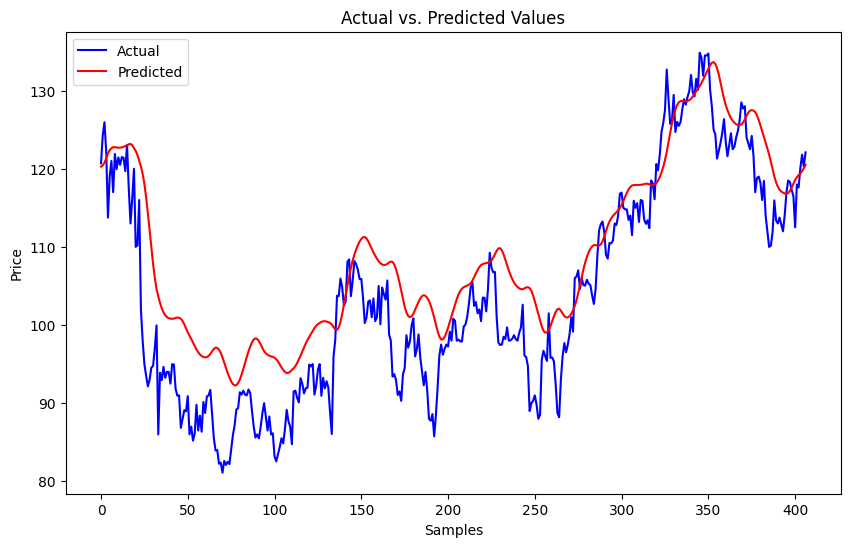

In [25]:
import matplotlib.pyplot as plt
# actual values from the original dataset (unscaled)
actual = dataset[training_data_len:, 0]

plt.figure(figsize=(10, 6))
plt.plot(actual, label='Actual', color='blue')
plt.plot(predictions[:, 0], label='Predicted', color='red')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.legend()
plt.show()

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `plt.plot(...)` | Plots the actual recorded stock prices alongside the predicted prices on a visual graph to evaluate model performance without raw numbers. |


---
## Exercise-02: Train a 2-layer bidirectional LSTM on IMDB data
**Objective:** Build a Sentiment Analysis Model with Bidirectional LSTMs.

🏃 **RUN**

Execute the cell below.

In [26]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import os
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


🏃 **RUN**

Execute the cell below.

In [27]:
# Only consider the top 20k words
# Only consider the first 200 words of each movie review
max_features = 20000
maxlen = 200

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [28]:
# [TODO] Input for variable-length sequences of integers
inputs = keras.Input(shape=(None,), dtype="int32")

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [29]:
# [TODO]  Embed each integer in a 128-dimensional vector
x = layers.Embedding(max_features, 128)(inputs)

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [30]:
# [TODO] Add 2 bidirectional LSTMs
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [31]:
# [TODO] Add a classifier, use Sigmoid as activation function
outputs = layers.Dense(1, activation ="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,761 (10.52 MB)

 Trainable params: 2,757,761 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [32]:
# [TODO] Load the IMDB movie review sentiment data
(x_train, y_train), (x_val, y_val) = keras.datasets.imdb.load_data(
    num_words=max_features
)
print(len(x_train), "Training sequence")
print(len(x_val), "Validation sequence")
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_val = keras.preprocessing.sequence.pad_sequences(x_val, maxlen=maxlen)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 Training sequence
25000 Validation sequence


### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [33]:
# [TODO] compile the model using adam optimizer and Binary cross-entropy as loss function
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


✏️ **TODO**

Implement the missing code below.

In [34]:
# [TODO] train the model set epochs to 2, batch size to 32
model.fit(x_train, y_train, batch_size=32, epochs=2, validation_data=(x_val, y_val))

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 359s 453ms/step - accuracy: 0.7365 - loss: 0.4972 - val_accuracy: 0.8429 - val_loss: 0.3732
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 353s 451ms/step - accuracy: 0.8988 - loss: 0.2629 - val_accuracy: 0.8640 - val_loss: 0.3126


### 💡 Detailed Code Explanation

| Syntax/Method | Description |
| ------------- | ----------- |
| `method()` | Description of the method. |


---
## 📚 Summary of Functions and Methods

Here is a summary of the key functions and methods used in this notebook:

| Library / Module | Syntax / Method | Description |
|------------------|-----------------|-------------|
| `sklearn.preprocessing` | `MinMaxScaler()` | Transforms features by scaling each feature to a given range. |
| `sklearn.preprocessing` | `fit_transform()` | Fits the transformer to the data and returns a transformed version. |
| `sklearn.preprocessing` | `inverse_transform()` | Undoes the scaling of data according to the feature range. |
| `numpy` | `np.array()` | Creates a numpy array from a list or list-like object. |
| `numpy` | `np.reshape()` | Gives a new shape to an array without changing its data. |
| `keras.models` | `Sequential()` | Initializes a linear stack of layers for a neural network model. |
| `keras.models` | `model.compile()` | Configures the model for training (sets optimizer, loss function, metrics). |
| `keras.models` | `model.fit()` | Trains the model on data for a fixed number of epochs. |
| `keras.models` | `model.predict()` | Generates output predictions for the input samples. |
| `keras.layers` | `LSTM()` | Adds a Long Short-Term Memory layer to the model. |
| `keras.layers` | `Dense()` | Adds a fully connected layer to the model. |
| `keras.layers` | `Bidirectional()` | Bidirectional wrapper for RNNs, allowing them to process sequences in both directions. |
| `keras.layers` | `Embedding()` | Turns positive integers (word indexes) into dense vectors of fixed size. |
| `keras` | `keras.Input()` | Used to instantiate a Keras tensor, typically for the input layer. |
| `keras.datasets` | `imdb.load_data()` | Loads the IMDB movie review dataset. |
| `keras.preprocessing.sequence` | `pad_sequences()` | Pads sequences to the same length so they can be processed as tensors. |
